<a href="https://colab.research.google.com/github/sparkiqai-codes/sparky_ismrait27/blob/main/Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!rm -rf sparky_ismrait27
!git clone https://github.com/sparkiqai-codes/sparky_ismrait27.git

Cloning into 'sparky_ismrait27'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 1001.08 KiB | 3.20 MiB/s, done.
Resolving deltas: 100% (7/7), done.


In [ ]:
import os

# Ensure we change to the expected root directory of the cloned repository
expected_repo_path = '/content/sparky_ismrait27'

if os.path.exists(expected_repo_path):
    os.chdir(expected_repo_path)
    print(f"Successfully changed directory to: {os.getcwd()}")
else:
    print(f"Error: '{expected_repo_path}' directory not found after git clone. Please check the git clone command output for errors.")
    print("Current directory contents of /content:")
    !ls -F /content

Successfully changed directory to: /content/sparky_ismrait27


In [ ]:
import os

# Configure Git user
!git config --global user.email "contactus@sparkiqai.co.in"
!git config --global user.name "sparkiqai-codes"

# Clean up and re-initialize git repository
# This handles cases where git clone might have left a partial or problematic .git
if os.path.exists('.git'):
    print("Removing existing .git directory...")
    !rm -rf .git
print("Initializing new git repository...")
!git init

# Add README.md
!git add README.md

# Commit the README.md
!git commit -m "Initial commit: Add README.md"

# Remove existing remote 'origin' if it exists before adding
# The '2>/dev/null || true' suppresses errors if origin doesn't exist.
!git remote rm origin 2>/dev/null || true
print("Setting remote origin...")
!git remote add origin https://github.com/sparkiqai-codes/sparky_ismrait27.git

# Set the branch name to main
!git branch -M main

print("Git repository configured and initial commit made.")
print("You are ready to push to the remote repository.")

Removing existing .git directory...
Initializing new git repository...
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/sparky_ismrait27/.git/
[master (root-commit) 79c6d61] Initial commit: Add README.md
 1 file changed, 1 insertion(+)
 create mode 100644 README.md
Setting remote origin...
Git repository configured and initial commit made.
You are ready to push to the remote repository.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Define the path to the CLIP_data folder in your Google Drive
clip_data_path = '/content/drive/My Drive/CLIP_data'

# Check if the folder exists and list its contents (optional, for verification)
if os.path.exists(clip_data_path):
    print(f"'CLIP_data' folder found at: {clip_data_path}")
    print("Contents of 'CLIP_data' folder:")
    !ls "{clip_data_path}"
else:
    print(f"Error: 'CLIP_data' folder not found at {clip_data_path}. Please ensure the folder exists in your Google Drive.")

'CLIP_data' folder found at: /content/drive/My Drive/CLIP_data
Contents of 'CLIP_data' folder:
clip_train.csv	frames.zip


In [ ]:
import pandas as pd

# Load the clip_train.csv file
clip_train_df = pd.read_csv(f'{clip_data_path}/clip_train.csv')

# Display the first few rows of the DataFrame
display(clip_train_df.head())

,image,text,label,class_name,safety_label,video_name
0,dataset/frames/0_safe_walkway_violation/0_tr1_...,Industrial safety hazard: a pedestrian has lef...,0,0_safe_walkway_violation,unsafe,0_tr1
1,dataset/frames/0_safe_walkway_violation/0_tr1_...,Unsafe pedestrian behavior: the worker is beyo...,0,0_safe_walkway_violation,unsafe,0_tr1
2,dataset/frames/0_safe_walkway_violation/0_tr1_...,Unsafe situation: a worker is outside the desi...,0,0_safe_walkway_violation,unsafe,0_tr1
3,dataset/frames/0_safe_walkway_violation/0_tr10...,Industrial safety hazard: a pedestrian has lef...,0,0_safe_walkway_violation,unsafe,0_tr100
4,dataset/frames/0_safe_walkway_violation/0_tr10...,Unsafe pedestrian behavior: the worker is beyo...,0,0_safe_walkway_violation,unsafe,0_tr100


In [ ]:
import zipfile
import os

# Path to the frames.zip file
zip_file_path = f'{clip_data_path}/frames.zip'

# Directory to extract the contents to
extract_path = clip_data_path # Extract into the same directory as clip_data_path

# Create the extraction directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

print(f"Extracting {zip_file_path} to {extract_path}...")

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        # Print the names of the files inside the zip to understand its structure
        print("Contents of frames.zip (first 10 files):")
        for i, name in enumerate(zip_ref.namelist()):
            if i < 10: # Print only first 10 for brevity
                print(name)
            else:
                print("...")
                break

        zip_ref.extractall(extract_path)
    print("Extraction complete.")

    # Verify extraction by listing contents of the clip_data_path directory
    print(f"Contents of {clip_data_path} after extraction (first 10 items):")
    extracted_contents = os.listdir(clip_data_path)
    for i, item in enumerate(extracted_contents):
        if i < 10:
            print(item)
        else:
            print("...")
            break

except FileNotFoundError:
    print(f"Error: Zip file not found at {zip_file_path}")
except Exception as e:
    print(f"An error occurred during zip extraction: {e}")


Extracting /content/drive/My Drive/CLIP_data/frames.zip to /content/drive/My Drive/CLIP_data...
Contents of frames.zip (first 10 files):
frames/
frames/0_safe_walkway_violation/
frames/0_safe_walkway_violation/0_tr100_00h00m00s.jpg
frames/0_safe_walkway_violation/0_tr100_00h00m05s.jpg
frames/0_safe_walkway_violation/0_tr101_00h00m00s.jpg
frames/0_safe_walkway_violation/0_tr101_00h00m05s.jpg
frames/0_safe_walkway_violation/0_tr102_00h00m00s.jpg
frames/0_safe_walkway_violation/0_tr102_00h00m05s.jpg
frames/0_safe_walkway_violation/0_tr103_00h00m00s.jpg
frames/0_safe_walkway_violation/0_tr103_00h00m05s.jpg
...
Extraction complete.
Contents of /content/drive/My Drive/CLIP_data after extraction (first 10 items):
clip_train.csv
frames.zip
frames


Attempting to load image from: /content/drive/My Drive/CLIP_data/frames/0_safe_walkway_violation/0_tr1_00h00m00s.jpg


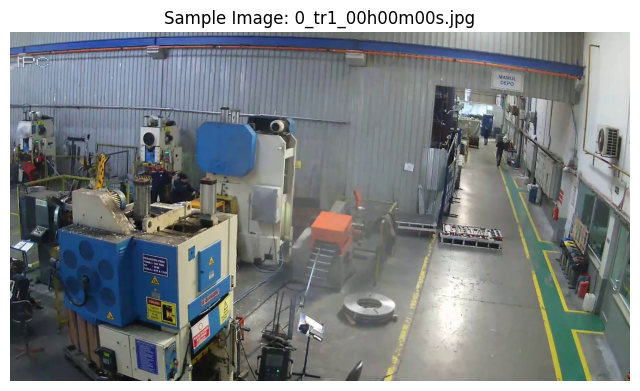

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# Get the path of the first image from the DataFrame
relative_image_path = clip_train_df.loc[0, 'image']

# Adjust the relative_image_path to match the actual extracted file structure
# The zip extracts 'frames/' directly into 'clip_data_path', but DataFrame paths start with 'dataset/frames/'.
# So, we need to remove the 'dataset/' prefix.
if relative_image_path.startswith('dataset/'):
    adjusted_image_path = relative_image_path[len('dataset/'):]
else:
    adjusted_image_path = relative_image_path

# Construct the full absolute path to the image
full_image_path = os.path.join(clip_data_path, adjusted_image_path)

print(f"Attempting to load image from: {full_image_path}")

try:
    # Load the image
    img = Image.open(full_image_path)

    # Display the image
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"Sample Image: {os.path.basename(full_image_path)}")
    plt.axis('off') # Hide axes ticks
    plt.show()
except FileNotFoundError:
    print(f"Error: Image file not found at {full_image_path}. Check extraction path and image paths.")
    print("Please verify the contents of the extracted directory.")
    expected_parent_dir = os.path.dirname(full_image_path)
    if os.path.exists(expected_parent_dir):
        print(f"Contents of {expected_parent_dir}:")
        !ls -F "{expected_parent_dir}"
    else:
        print(f"Expected parent directory {expected_parent_dir} does not exist.")
except Exception as e:
    print(f"An error occurred while loading or displaying the image: {e}")

To encode images using the `SentenceTransformer` model, we need to prepare a list of image objects (e.g., PIL Image) and text captions. The `clip-ViT-B-32` model will then convert these into numerical embeddings.

In [ ]:
from PIL import Image

# Let's take the first 5 images from the DataFrame for demonstration
sample_image_paths = clip_train_df['image'].tolist()

images = []
for relative_path in sample_image_paths:
    # Adjust the relative path as we did previously
    if relative_path.startswith('dataset/'):
        adjusted_path = relative_path[len('dataset/'):]
    else:
        adjusted_path = relative_path

    full_path = os.path.join(clip_data_path, adjusted_path)
    try:
        img = Image.open(full_path)
        images.append(img)
    except FileNotFoundError:
        print(f"Warning: Image not found at {full_path}. Skipping.")
    except Exception as e:
        print(f"An error occurred loading {full_path}: {e}")

# Create some dummy captions corresponding to these images for demonstration
captions = [
    "Unsafe equipment interaction: an unauthorized person is performing an intervention.",
    "a pedestrian has left the designated walking route.",
    "Safe situation: material is being carried correctly and securely.",
    "Industrial transport hazard: a forklift is moving an unsafe load.",
    "Unsafe equipment condition: the protective panel cover is not closed."
]

print(f"Prepared {len(images)} images and {len(captions)} captions for encoding.")

Prepared 854 images and 5 captions for encoding.


In [ ]:
from sentence_transformers import SentenceTransformer, util

In [ ]:
# Load SBERT-compatible CLIP model
model = SentenceTransformer('clip-ViT-B-32')

# Encode the images
image_embeddings = model.encode(images)

# Encode the captions
text_embeddings = model.encode(captions)

# # Compute cosine similarities
# sim_matrix = util.cos_sim(text_embeddings, image_embeddings)


# Calculate cosine similarity
cosine_scores = util.cos_sim(text_embeddings, image_embeddings)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
cosine_scores

tensor([[0.2495, 0.2493, 0.2503,  ..., 0.2652, 0.2639, 0.2679],
        [0.1749, 0.1668, 0.1693,  ..., 0.2074, 0.2078, 0.2101],
        [0.2542, 0.2462, 0.2495,  ..., 0.2425, 0.2435, 0.2419],
        [0.2433, 0.2492, 0.2475,  ..., 0.2713, 0.2706, 0.2711],
        [0.2424, 0.2431, 0.2463,  ..., 0.2433, 0.2441, 0.2498]])

### Visualize the Best Matching Image for a Caption

We will now take one of the captions and find which image it is most similar to based on the calculated `cosine_scores`. Then, we will display that image.

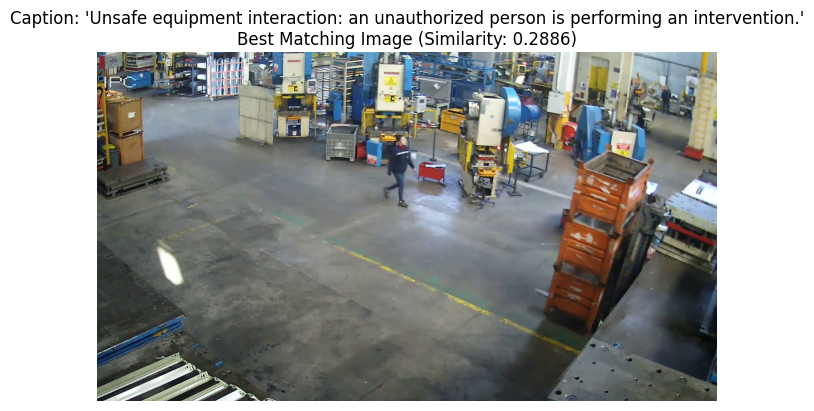

In [ ]:
import matplotlib.pyplot as plt

# Let's pick the first caption as an example
caption_index = 0
chosen_caption = captions[caption_index]

# Get the similarity scores for the chosen caption across all images
caption_similarity_scores = cosine_scores[caption_index]

# Find the index of the image with the highest similarity score
best_match_image_index = caption_similarity_scores.argmax().item()

# Retrieve the best matching image
best_match_image = images[best_match_image_index]

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(best_match_image)
plt.title(f"Caption: '{chosen_caption}'\nBest Matching Image (Similarity: {caption_similarity_scores[best_match_image_index]:.4f})")
plt.axis('off')
plt.show()


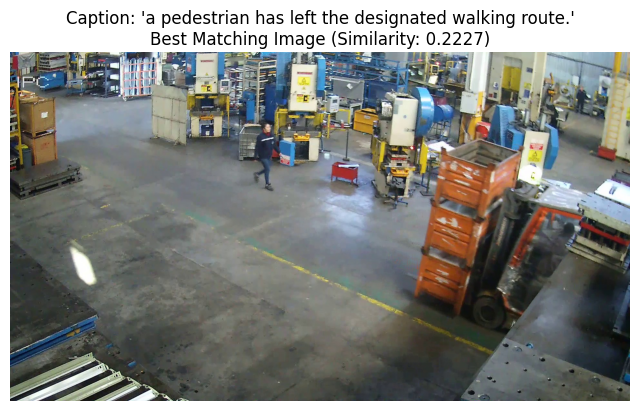

In [ ]:
# Let's pick the first caption as an example
caption_index = 1
chosen_caption = captions[caption_index]

# Get the similarity scores for the chosen caption across all images
caption_similarity_scores = cosine_scores[caption_index]

# Find the index of the image with the highest similarity score
best_match_image_index = caption_similarity_scores.argmax().item()

# Retrieve the best matching image
best_match_image = images[best_match_image_index]

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(best_match_image)
plt.title(f"Caption: '{chosen_caption}'\nBest Matching Image (Similarity: {caption_similarity_scores[best_match_image_index]:.4f})")
plt.axis('off')
plt.show()

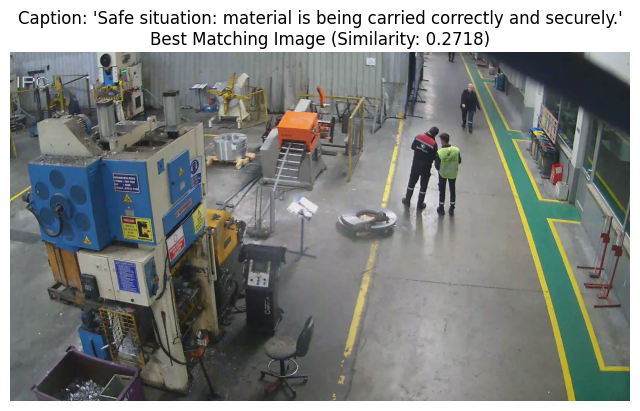

In [ ]:
# Let's pick the first caption as an example
caption_index = 2
chosen_caption = captions[caption_index]

# Get the similarity scores for the chosen caption across all images
caption_similarity_scores = cosine_scores[caption_index]

# Find the index of the image with the highest similarity score
best_match_image_index = caption_similarity_scores.argmax().item()

# Retrieve the best matching image
best_match_image = images[best_match_image_index]

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(best_match_image)
plt.title(f"Caption: '{chosen_caption}'\nBest Matching Image (Similarity: {caption_similarity_scores[best_match_image_index]:.4f})")
plt.axis('off')
plt.show()

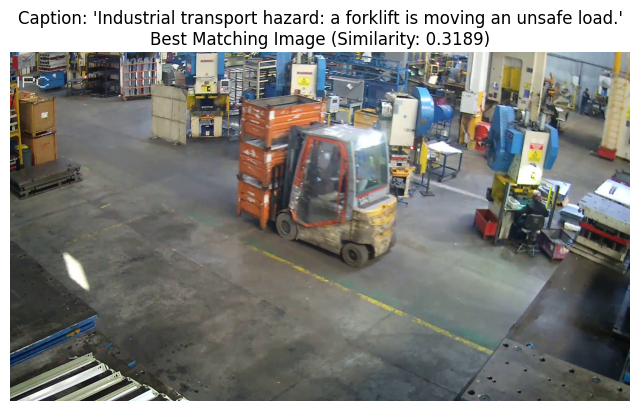

In [ ]:
# Let's pick the first caption as an example
caption_index = 3
chosen_caption = captions[caption_index]

# Get the similarity scores for the chosen caption across all images
caption_similarity_scores = cosine_scores[caption_index]

# Find the index of the image with the highest similarity score
best_match_image_index = caption_similarity_scores.argmax().item()

# Retrieve the best matching image
best_match_image = images[best_match_image_index]

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(best_match_image)
plt.title(f"Caption: '{chosen_caption}'\nBest Matching Image (Similarity: {caption_similarity_scores[best_match_image_index]:.4f})")
plt.axis('off')
plt.show()

### Generate Descriptive Captions using Gemini API

To use the Gemini API, you'll need an API key. If you don't already have one, create a key in Google AI Studio. In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GOOGLE_API_KEY`. Then, you can configure the Gemini client.

In [ ]:
import google.generativeai as genai
from google.colab import userdata

# Configure the Gemini API client with your API key
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

print("Gemini API configured successfully!")


Gemini API configured successfully!


Now, let's use a Gemini model to generate a descriptive caption for one of your images. We will use the first image from our `images` list.

In [ ]:
# Select a generative model that supports vision inputs
model = genai.GenerativeModel('gemini-3.7-flash')

# Take the first image from our 'images' list
sample_image_for_caption = images[0]

# Generate a caption for the image
response = model.generate_content([
    "Describe this image in detail, focusing on any safety-related elements or activities.",
    sample_image_for_caption
])

# Print the generated caption
print("Generated Caption:")
print(response.text)


Generated Caption:
### **Overview of the Scene**
The image captures an industrial manufacturing or metal-stamping workshop viewed from an elevated surveillance angle. The facility is equipped with heavy industrial machinery, including large mechanical stamping presses, metal sheet feeding mechanisms, and overhead structural beams. The layout is divided into active machine operation zones on the left and center, and a pedestrian/transit aisle on the right leading toward an entrance marked **"MAMUL DEPO"** (Finished Goods Storage).

---

### **Key Machinery and Workflow**
* **Stamping Presses:** 
  * In the foreground and mid-ground on the left stand large mechanical presses painted in blue and off-white/beige. 
  * Technical and capacity specification plates (e.g., indicating tonnage such as "100 TON") are mounted on the operator panels.
* **Coil Feeder & Sheet Metal Line:**
  * In the center, an orange feeding/straightening unit supplies strip metal directly into the adjacent press.
  

In [ ]:
import os

# Get the name of the current notebook file
# This assumes the notebook is saved in Google Drive with this name.
notebook_filename = 'Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM.ipynb'

# Source path: Assume the notebook is saved in 'My Drive/Colab Notebooks/' (a common default location)
source_path = os.path.join('./drive/MyDrive', notebook_filename)


In [ ]:
destination_path = os.path.join('./sparky_ismrait27',  notebook_filename)

In [ ]:
!cp "{source_path}" "{destination_path}"

cp: cannot stat './drive/MyDrive/Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM.ipynb': No such file or directory


In [ ]:
# Destination path (current working directory is sparky_ismrait27)
# destination_path = os.path.join(os.getcwd(), notebook_filename)

print(f"Copying {source_path} to {destination_path}...")
# Check if the source file exists before attempting to copy
if os.path.exists(source_path):
    !cp "{source_path}" "{destination_path}"
    print("Notebook copied.")
else:
    print(f"Error: Notebook file not found at {source_path}. Please ensure the notebook is saved in your Google Drive with the specified filename.")
    # If the file wasn't found, we can't reliably add/commit it.
    # We'll still proceed with git commands, but they might operate on an old or empty file.

# Add the new notebook to git
print(f"Adding {notebook_filename} to git...")
!git add "{notebook_filename}"

# Commit the changes
print(f"Committing {notebook_filename}...")
!git commit -m "Update {notebook_filename} in repository"

print("Notebook added and committed to Git.")


Copying /content/drive/My Drive/Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM.ipynb to /content/sparky_ismrait27/Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM.ipynb...
Error: Notebook file not found at /content/drive/My Drive/Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM.ipynb. Please ensure the notebook is saved in your Google Drive with the specified filename.
Adding Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM.ipynb to git...
Committing Multi_agent_based_Industrial_Safety_Risk_Prediction_with_State_Transition_with_fine_tuned_VLM.ipynb...
On branch main
Untracked files:
  (use "git add <file>..." to include in what will be committed)
	SECURITY.md

nothing added to commit but untracked files present (use "git add" to track)
Notebook added and committed to Git.
